In [2]:
!pip install bertopic
!pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5

In [3]:
import pandas as pd
import numpy as np
import torch
import transformers
from bertopic import BERTopic
import os
from sentence_transformers import SentenceTransformer
from umap import UMAP
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from hdbscan import HDBSCAN
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt
import openai
import lightgbm as lgb
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance, OpenAI, PartOfSpeech
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Read Data

In [6]:
os.chdir('/content/drive/My Drive/NLP-Letters-V2/notebooks/')
df1 = pd.read_csv('../data/letters_2021_processed.csv')
df1 = df1[['s1_s2', 'full_text', 'LETTER_GENDER']]
df1 = df1.rename(columns={'LETTER_GENDER':'label'})

In [7]:
df2 = pd.read_csv('../data/sentence_sets_trimmed_processed.csv')
df2 = df2[['s1_s2', 'full_text', 'applicant_gender']]
df2 = df2.rename(columns={'applicant_gender':'label'})

In [8]:
df = pd.concat([df1, df2], ignore_index=True)

In [9]:
gender_label_mapping = {
    'F':0,
    'female':0,
    'M':1,
    'male':1
}

In [10]:
df['label'] = df['label'].replace(gender_label_mapping)

# Process Data

In [11]:
letters = df['s1_s2']
sentences = [sent_tokenize(letter) for letter in letters]
sentences = pd.concat([df, pd.Series(sentences, name='sentences')], axis=1)
sentences = sentences[['sentences']].explode('sentences')
df_sentences = pd.merge(df, sentences, left_index=True, right_index=True)

# Topic Modeling

In [12]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embedding_model.encode(sentences['sentences'].tolist(), show_progress_bar=True)

umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

hdbscan_model = HDBSCAN(min_cluster_size=150, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

vectorizer_model = CountVectorizer(stop_words="english", min_df=2, ngram_range=(1, 3))

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/4850 [00:00<?, ?it/s]

In [13]:
# KeyBERT
keybert_model = KeyBERTInspired()

# Part-of-Speech
pos_model = PartOfSpeech("en_core_web_sm")

# MMR
mmr_model = MaximalMarginalRelevance(diversity=0.9)

# GPT-3.5
client = openai.OpenAI(api_key="sk-...")
prompt = """
I have a topic that contains the following documents:
[DOCUMENTS]
The topic is described by the following keywords: [KEYWORDS]

Based on the information above, extract a short but highly descriptive topic label of at most 5 words. Make sure it is in the following format:
topic: <topic label>
"""
openai_model = OpenAI(client, model="gpt-3.5-turbo", exponential_backoff=True, chat=True, prompt=prompt)

# All representation models
representation_model = {
    "KeyBERT": keybert_model,
    # "OpenAI": openai_model,  # Uncomment if you will use OpenAI
    "MMR": mmr_model,
    "POS": pos_model
}

In [14]:
topic_model = BERTopic(

  # Pipeline models
  embedding_model=embedding_model,
  umap_model=umap_model,
  hdbscan_model=hdbscan_model,
  vectorizer_model=vectorizer_model,
  # ctfidf_model=ctfidf_model,
  representation_model=representation_model,

  # Hyperparameters
  top_n_words=10,
  verbose=True
)

# Train model
topics, probs = topic_model.fit_transform(df_sentences['sentences'].tolist(), embeddings)



2025-02-05 21:06:35,156 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-02-05 21:12:15,433 - BERTopic - Dimensionality - Completed ✓
2025-02-05 21:12:15,443 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-02-05 21:12:52,903 - BERTopic - Cluster - Completed ✓
2025-02-05 21:12:52,936 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-02-05 21:13:20,480 - BERTopic - Representation - Completed ✓


# Analyze Topics

In [15]:
topic_info = topic_model.get_topic_info()

In [16]:
topic_info

,Topic,Count,Name,Representation,KeyBERT,MMR,POS,Representative_Docs
0,-1,56497,-1_identifier_medical_clinical_research,"[identifier, medical, clinical, research, work...","[dr identifier, identifier, identifier identif...","[medical, research, care, worked, identifier i...","[identifier, medical, clinical, research, work...",[i am writing this letter in support of ident...
1,0,11879,0_anesthesiology_anesthesia_identifier_residency,"[anesthesiology, anesthesia, identifier, resid...","[identifier anesthesiology residency, anesthes...","[rotation, program, anesthesiology residency p...","[anesthesiology, anesthesia, identifier, resid...","[in closing , i enthusiastically recommend id..."
2,1,10770,1_patients_patient_care_clinical,"[patients, patient, care, clinical, knowledge,...","[patients staff, patients, care patients, pati...","[care, knowledge, staff, manner, rapport, exce...","[patients, patient, care, clinical, knowledge,...",[they is able to communicate with ease around...
3,2,7447,2_identifier_work_person_student,"[identifier, work, person, student, individual...","[identifier, identifier identifier, identifier...","[person, hard, motivated, work ethic, personal...","[identifier, work, person, student, individual...","[on a personal level , identifier is mature ..."
4,3,4126,3_anesthesiology_anesthesiologist_career_field,"[anesthesiology, anesthesiologist, career, fie...","[make excellent anesthesiologist, anesthesiolo...","[field, career anesthesiology, make, believe, ...","[anesthesiology, anesthesiologist, career, fie...",[they will be an outstanding anesthesiologist...
...,...,...,...,...,...,...,...,...
89,88,178,88_waived right view_right view_letter identif...,"[waived right view, right view, letter identif...","[letter identifier waived, identifier waived r...","[right view, view letter identifier, right, le...","[right, letter, rights, contents, identifier, ...",[identifier has waived their right to view ...
90,89,169,89_late_stayed_early_stayed late,"[late, stayed, early, stayed late, early staye...","[early stayed late, early stays late, arrived ...","[late, day, leave, came, ready, showed early, ...","[late, early, day, time, ready, morning, hours...","[they arrived early and stayed late ., they ..."
91,90,158,90_application_consideration_hope_hope applica...,"[application, consideration, hope, hope applic...","[thank considering application, application th...","[hope, thank, support, endorse, application st...","[application, consideration, support, strong c...",[i hope you will give their application ever...
92,91,157,91_enjoys_music_playing_hiking,"[enjoys, music, playing, hiking, musician, spa...","[identifier enjoys sports, enjoys sports, enjo...","[hiking, spare time, hobbies, cooking, loves, ...","[music, hiking, musician, spare time, spare, h...",[in their spare time identifier enjoys spo...


In [17]:
topic_model.get_topic(10, full=True)

{'Main': [('person', 0.024311036048319187),
  ('intelligent', 0.02377277532212709),
  ('hard working', 0.02298710648771738),
  ('hard', 0.022049545013472224),
  ('calm', 0.02177290702988636),
  ('demeanor', 0.021097691137887245),
  ('motivated', 0.02060959697408592),
  ('mature', 0.019019588323906513),
  ('humble', 0.01886759000610297),
  ('personality', 0.018851241324803755)],
 'KeyBERT': [('pleasant personality', 0.52010465),
  ('calm demeanor', 0.4870573),
  ('demeanor', 0.45641762),
  ('personality', 0.44439903),
  ('interpersonal skills', 0.4169492),
  ('strong work ethic', 0.40418097),
  ('skills', 0.4016619),
  ('excellent communication', 0.39725053),
  ('communication skills', 0.39282963),
  ('personable', 0.39047748)],
 'MMR': [('hard', 0.022049545013472224),
  ('calm', 0.02177290702988636),
  ('motivated', 0.02060959697408592),
  ('personality', 0.018851241324803755),
  ('ethic', 0.01691102377844753),
  ('communication', 0.016697116094758463),
  ('professional', 0.01659242620

In [18]:
topic_labels = topic_model.generate_topic_labels(nr_words=5,
                                                 topic_prefix=True,
                                                 word_length=20,
                                                 separator="||",
                                                 aspect='MMR')

In [19]:
topic_model.set_topic_labels(topic_labels)

In [20]:
topic_mapping = dict(zip(topic_model.get_topic_info()['Topic'], topic_model.get_topic_info()['CustomName']))
topic_mapping = {f'topic_{key}': value for key, value in topic_mapping.items()}

In [21]:
df_sentences['topic'] = topics

# Create Topics Dataframe

In [22]:
topics_df = df_sentences.copy()
topics_df['topic'] = topics_df['topic'].astype(str)
topics_df = topics_df.groupby(topics_df.index).agg({'topic':' '.join})
topics_df = pd.DataFrame(topics_df)
topics_df = topics_df['topic'].apply(lambda x:x.split(' '))
topics_df = topics_df.reset_index()
all_topics = set(cat for sublist in topics_df['topic'] for cat in sublist)
for topic in all_topics:
    topics_df[topic] = topics_df['topic'].apply(lambda x: 1 if topic in x else 0)
topics_df = topics_df.drop(columns=['index', 'topic'])
topics_df.columns = 'topic_' + topics_df.columns
df_sentences_collapsed = df_sentences[['s1_s2', 'full_text', 'label']].drop_duplicates()
topics_df = pd.merge(df_sentences_collapsed, topics_df, left_index=True, right_index=True)

# Build ML Model

In [23]:
X = topics_df.drop(columns=['s1_s2', 'full_text', 'label'])
y = topics_df['label']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [25]:
skf = StratifiedKFold(n_splits=5)

In [26]:
# clf = RandomForestClassifier(class_weight='balanced', random_state=42)
clf = lgb.LGBMClassifier(is_unbalance=True, verbose=-1)

In [27]:
best_classifier = None
best_f1_score = float('-inf')
for i, (train_index, val_index) in enumerate(skf.split(X_train, y_train)):
    print(f"Fold {i}:")
    # print(f"  Train: index={train_index}")
    # print(f"  Test:  index={val_index}")

    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    clf.fit(X_train_fold, y_train_fold)

    y_pred = clf.predict(X_val_fold)

    print(classification_report(y_val_fold, y_pred))

    print(confusion_matrix(y_val_fold, y_pred))

    f1 = f1_score(y_val_fold, y_pred, average='weighted')

    if f1 > best_f1_score:
      print('BEST F1 SCORE: ', f1)
      best_f1_score = f1
      best_classifier = clf






Fold 0:
              precision    recall  f1-score   support

           0       0.32      0.37      0.34       446
           1       0.70      0.64      0.67       991

    accuracy                           0.56      1437
   macro avg       0.51      0.51      0.51      1437
weighted avg       0.58      0.56      0.57      1437

[[166 280]
 [352 639]]
BEST F1 SCORE:  0.5683295879375231
Fold 1:
              precision    recall  f1-score   support

           0       0.34      0.39      0.36       446
           1       0.70      0.65      0.68       991

    accuracy                           0.57      1437
   macro avg       0.52      0.52      0.52      1437
weighted avg       0.59      0.57      0.58      1437

[[175 271]
 [347 644]]
BEST F1 SCORE:  0.5782458171801331
Fold 2:
              precision    recall  f1-score   support

           0       0.32      0.37      0.34       446
           1       0.70      0.66      0.68       991

    accuracy                           0.5

Most Important Features:
                                              Feature  Importance
33   2||person||hard||motivated||work ethic||personal         177
46         1||care||knowledge||staff||manner||rapport         162
63  3||field||career anesthesiolog||make||believe|...         139
78  4||anesthesia residency||rotation||care||quest...         127
83  5||compassion||demonstrated||rapport||skills||...         119
36  6||residency program id||program identifier||p...         113
39    8||program||asset||addition||recommend||believe         106
88  0||rotation||program||anesthesiology resid||re...         102
71      10||hard||calm||motivated||personality||ethic          80
89      11||recommend||matches||addition||lucky||stay          67
62  15||medical student iden||students worked||wor...          66
75  18||recommendation||letter recommendatio||plea...          60
76  17||publications||peer||data||abstracts||national          59
45  9||airway management||mask||endotracheal||peri.

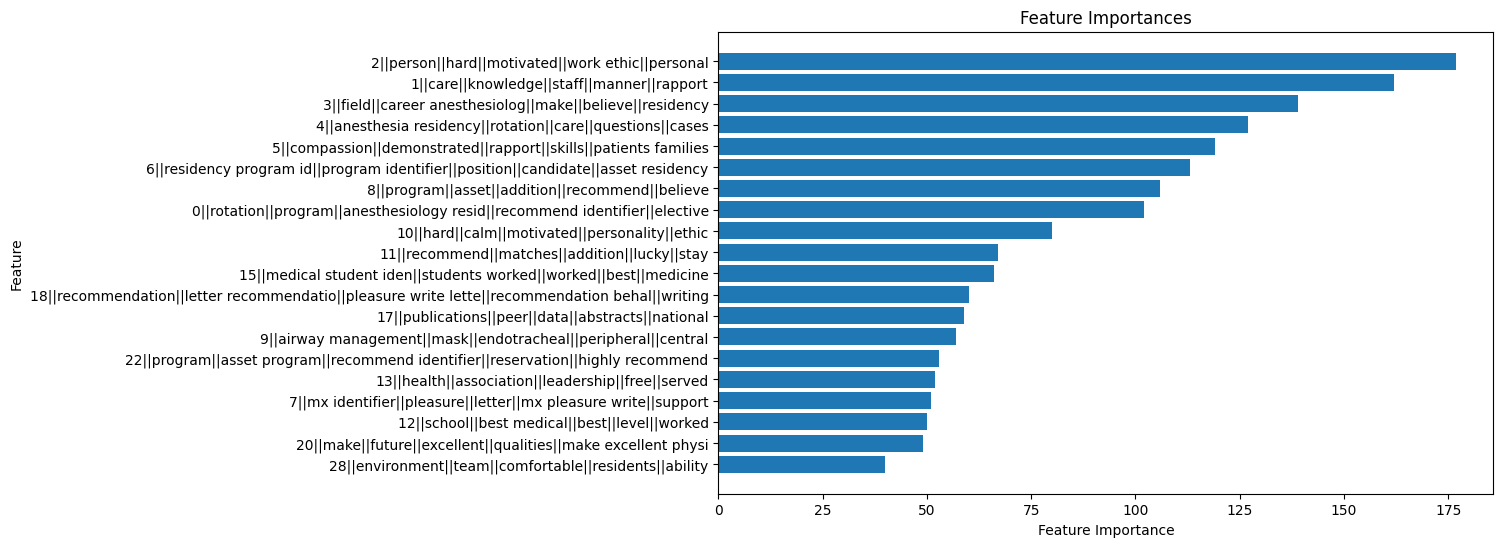

In [28]:
importances = best_classifier.feature_importances_

feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)[:20]
feature_importance_df['Feature'] = feature_importance_df['Feature'].map(topic_mapping)

print("Most Important Features:")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importances')

plt.gca().invert_yaxis()

plt.show()

In [29]:
topic_model.get_topic(3, full=True)

{'Main': [('anesthesiology', 0.044805149382443746),
  ('anesthesiologist', 0.04243659661311523),
  ('career', 0.01629681411630471),
  ('field', 0.014321850806291413),
  ('career anesthesiology', 0.013435055960335852),
  ('field anesthesiology', 0.013039568567456535),
  ('make', 0.012385840417130218),
  ('anesthesiology residency', 0.012184374166641036),
  ('believe', 0.01177303947968789),
  ('future', 0.010464592978544485)],
 'KeyBERT': [('make excellent anesthesiologist', 0.8895852),
  ('anesthesiologists', 0.87548953),
  ('future anesthesiologist', 0.8737513),
  ('excellent anesthesiologist', 0.8672818),
  ('anesthesiologist', 0.84981024),
  ('successful anesthesiologist', 0.8460239),
  ('career anesthesiologist', 0.84543675),
  ('great anesthesiologist', 0.83499247),
  ('outstanding anesthesiologist', 0.816717),
  ('anesthesiology career', 0.81631756)],
 'MMR': [('field', 0.014321850806291413),
  ('career anesthesiology', 0.013435055960335852),
  ('make', 0.012385840417130218),
  ('

In [30]:
topic_model.get_topic_info()

,Topic,Count,Name,CustomName,Representation,KeyBERT,MMR,POS,Representative_Docs
0,-1,56497,-1_identifier_medical_clinical_research,-1||medical||research||care||worked||identifie...,"[identifier, medical, clinical, research, work...","[dr identifier, identifier, identifier identif...","[medical, research, care, worked, identifier i...","[identifier, medical, clinical, research, work...",[i am writing this letter in support of ident...
1,0,11879,0_anesthesiology_anesthesia_identifier_residency,0||rotation||program||anesthesiology resid||re...,"[anesthesiology, anesthesia, identifier, resid...","[identifier anesthesiology residency, anesthes...","[rotation, program, anesthesiology residency p...","[anesthesiology, anesthesia, identifier, resid...","[in closing , i enthusiastically recommend id..."
2,1,10770,1_patients_patient_care_clinical,1||care||knowledge||staff||manner||rapport,"[patients, patient, care, clinical, knowledge,...","[patients staff, patients, care patients, pati...","[care, knowledge, staff, manner, rapport, exce...","[patients, patient, care, clinical, knowledge,...",[they is able to communicate with ease around...
3,2,7447,2_identifier_work_person_student,2||person||hard||motivated||work ethic||personal,"[identifier, work, person, student, individual...","[identifier, identifier identifier, identifier...","[person, hard, motivated, work ethic, personal...","[identifier, work, person, student, individual...","[on a personal level , identifier is mature ..."
4,3,4126,3_anesthesiology_anesthesiologist_career_field,3||field||career anesthesiolog||make||believe|...,"[anesthesiology, anesthesiologist, career, fie...","[make excellent anesthesiologist, anesthesiolo...","[field, career anesthesiology, make, believe, ...","[anesthesiology, anesthesiologist, career, fie...",[they will be an outstanding anesthesiologist...
...,...,...,...,...,...,...,...,...,...
89,88,178,88_waived right view_right view_letter identif...,88||right view||view letter identifi||right||l...,"[waived right view, right view, letter identif...","[letter identifier waived, identifier waived r...","[right view, view letter identifier, right, le...","[right, letter, rights, contents, identifier, ...",[identifier has waived their right to view ...
90,89,169,89_late_stayed_early_stayed late,89||late||day||leave||came||ready,"[late, stayed, early, stayed late, early staye...","[early stayed late, early stays late, arrived ...","[late, day, leave, came, ready, showed early, ...","[late, early, day, time, ready, morning, hours...","[they arrived early and stayed late ., they ..."
91,90,158,90_application_consideration_hope_hope applica...,90||hope||thank||support||endorse||application...,"[application, consideration, hope, hope applic...","[thank considering application, application th...","[hope, thank, support, endorse, application st...","[application, consideration, support, strong c...",[i hope you will give their application ever...
92,91,157,91_enjoys_music_playing_hiking,91||hiking||spare time||hobbies||cooking||loves,"[enjoys, music, playing, hiking, musician, spa...","[identifier enjoys sports, enjoys sports, enjo...","[hiking, spare time, hobbies, cooking, loves, ...","[music, hiking, musician, spare time, spare, h...",[in their spare time identifier enjoys spo...


# Apply on Test Set

In [31]:
y_test_preds = best_classifier.predict(X_test)

In [32]:
print(classification_report(y_test, y_test_preds))

              precision    recall  f1-score   support

           0       0.32      0.40      0.35       557
           1       0.70      0.62      0.66      1239

    accuracy                           0.55      1796
   macro avg       0.51      0.51      0.51      1796
weighted avg       0.58      0.55      0.56      1796

